In [5]:
!pip install matplotlib

  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/fd/14/baad3222f424b19ce6ad243c71de1ad9ec6b2e4eb1e458a48fdc6d120401/matplotlib-3.10.8-cp311-cp311-macosx_11_0_arm64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.5 MB/s eta 0:00:00
  Obtaining dependency information for contourpy>=1.0.1 from https://files.pythonhosted.org/packages/0d/44/c4b0b6095fef4dc9c420e041799591e3b63e9619e3044f7f4f6c21c0ab24/contourpy-1.3.3-cp311-cp311-macosx_11_0_arm64.whl.metadata
  Obtaining dependency information for cycler>=0.10 from https://files.pythonhosted.org/packages/e7/05/c19819d5e3d95294a6f5947fb9b9629efb316b96de511b418c53d245aae6/cycler-0.12.1-py3-none-any.whl.metadata
  Obtaining dependency information for fonttools>=4.22.0 from https://files.pythonhosted.org/packages/69/12/bf9f4eaa2fad039356cc627587e30ed008c03f1cebd3034376b5ee8d1d44/fonttools-4.61.1-cp311-cp311-macosx_10_9_universal2.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Calculating term frequency(TF)

def term_frequency(word, document):
    return document.count(word)/len(document)
tf = term_frequency

In [7]:
Document = "My dog is the best dog that ever was a pet dog"
document_words = Document.split()
print("Dog TF score is:", term_frequency("dog", document_words))
print("Pet TF score is:", term_frequency("pet", document_words))

Dog TF score is: 0.25
Pet TF score is: 0.08333333333333333


In [17]:
# Alternative ways of implementing TF
# 1. Returns a boolean if a word exists in doc
def tf_boolean(word, document):
    return word in document
print("Dog TF boolean score is:", tf_boolean("dog", document_words))
print("Pet TF boolean score is:", tf_boolean("pet", document_words))

Dog TF boolean score is: True
Pet TF boolean score is: True


In [19]:
# 2. Sum - TF will be the count of words in a doc
def tf_summation(word, document):
    return document.count(word)
print("Dog TF summation score is:", tf_summation("dog", document_words))
print("Pet TF summation score is:", tf_summation("pet", document_words))

Dog TF summation score is: 3
Pet TF summation score is: 1


In [21]:
# 3. Logarithimically scaled TF
def tf_log_scaled(word, document):
    return np.log10(1 + document.count(word))
print("Dog TF log scaled score is:", tf_log_scaled("dog", document_words))
print("Pet TF log sclaed score is:", tf_log_scaled("pet", document_words))

Dog TF log scaled score is: 0.6020599913279624
Pet TF log sclaed score is: 0.3010299956639812


In [23]:
# Calculating inverse document frequency (IDF)
# Code below describes two ways in calcuating IDF

def inverse_document_frequency_unsafe(word, corpus):
    count_of_documents = len(corpus)
    count_of_documents_with_word = sum([1 for doc in corpus if word in doc])
    idf = np.log10(count_of_documents/count_of_documents_with_word)
    return idf

def inverse_document_frequency(word, corpus):
    count_of_documents = len(corpus) + 1
    count_of_documents_with_word = sum([1 for doc in corpus if word in doc]) + 1
    idf = np.log10(count_of_documents/count_of_documents_with_word) + 1
    return idf

idf = inverse_document_frequency

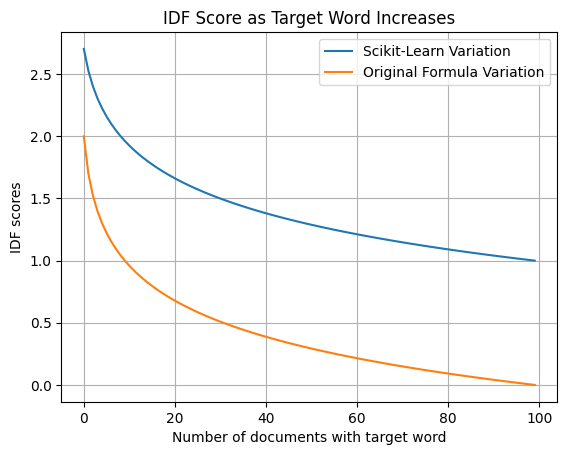

In [31]:
# Visualization of how idf scores changes if target word increases

corpus = [["word"] for i in range(100)]
idf_scores_unsafe = []
idf_scores = []
for i in range(100):
    corpus[i][0] = "target"
    idf_scores.append(inverse_document_frequency("target", corpus))
    idf_scores_unsafe.append(inverse_document_frequency_unsafe("target", corpus))

plt.plot(range(100), idf_scores, label = "Scikit-Learn Variation")
plt.plot(range(100), idf_scores_unsafe, label = "Original Formula Variation")
plt.legend()
plt.xlabel("Number of documents with target word")
plt.ylabel("IDF scores")
plt.title("IDF Score as Target Word Increases")
plt.grid(True)
plt.show()

In [35]:
# Calculating TF-IDF
def TF_IDF(word, document, corpus):
    return tf(word, document) * idf(word, corpus)

In [41]:
# Calculating the tf-idf score for the word "dog"
corpus_unsplit = [
    "My dog can play fetch really well",
    "I had a dog that didn't really look like a dog but was a dog",
    "dog bunny cat bunny rooster dog pig goat horse dog dog cat cow sealion bird pidgeon penguins and whales and treasure chests and what other random items can go into this long document I wonder",
    "I have a cat",
    "I have a goat",
    "Why is everyone talking about their pets",
    "I have a zebra",
    "You don't have a zebra Timmy"
]
corpus = [c.split() for c in corpus_unsplit]
target_word = "dog"
print("Searching for the word '%s'" %target_word)
for i, document in enumerate(corpus):
    tf_score = tf(target_word, document)
    idf_score = idf(target_word, corpus)
    tf_idf_score = TF_IDF(target_word, document, corpus)

    print("Document %s: %s \n tf score:%s \n idf score:%s \n tf_idf score:%s" %(i, document, tf_score, idf_score, tf_idf_score))
    print("-"*40)

Searching for the word 'dog'
Document 0: ['My', 'dog', 'can', 'play', 'fetch', 'really', 'well'] 
 tf score:0.14285714285714285 
 idf score:1.3521825181113625 
 tf_idf score:0.19316893115876604
----------------------------------------
Document 1: ['I', 'had', 'a', 'dog', 'that', "didn't", 'really', 'look', 'like', 'a', 'dog', 'but', 'was', 'a', 'dog'] 
 tf score:0.2 
 idf score:1.3521825181113625 
 tf_idf score:0.2704365036222725
----------------------------------------
Document 2: ['dog', 'bunny', 'cat', 'bunny', 'rooster', 'dog', 'pig', 'goat', 'horse', 'dog', 'dog', 'cat', 'cow', 'sealion', 'bird', 'pidgeon', 'penguins', 'and', 'whales', 'and', 'treasure', 'chests', 'and', 'what', 'other', 'random', 'items', 'can', 'go', 'into', 'this', 'long', 'document', 'I', 'wonder'] 
 tf score:0.11428571428571428 
 idf score:1.3521825181113625 
 tf_idf score:0.15453514492701284
----------------------------------------
Document 3: ['I', 'have', 'a', 'cat'] 
 tf score:0.0 
 idf score:1.3521825181

In [153]:
# TF-IDF vector
# Here we will construct a word vector that will give the tf-idf value of each unique word in the corpus
corpus_unsplit = [
    "My dog can play fetch really well",
    "I had a dog that didn't really look like a dog but was a dog",
    "dog bunny cat bunny rooster dog pig goat horse dog dog cat cow sealion bird pidgeon penguins and whales and treasure chests and what other random items can go into this long document I wonder",
    "I have a cat",
    "I have a goat",
    "Why is everyone talking about their pets",
    "I have a zebra",
    "You don't have a zebra Timmy"
]
corpus = [c.split() for c in corpus_unsplit]
num_documents = len(corpus)

In [154]:
# Create word vector for each documenet in the corpus
# List of unique words in the corpus
word_list = list(dict.fromkeys(word for document in corpus for word in document))
num_words = len(word_list)

# Create an index for each word
word_to_index = {word:i for i, word in enumerate(word_list)}

# Create empty list to store word vector for each document
word_vector = []

for document in corpus:
    new_word_vector = [0 for i in range(num_words)]

    for word in document:
        tf_idf_score = TF_IDF(word, document, corpus)
        word_index = word_to_index[word]

        new_word_vector[word_index] = float(tf_idf_score)

    word_vector.append(new_word_vector)

In [157]:
print(corpus_unsplit[1])

I had a dog that didn't really look like a dog but was a dog


In [159]:
print(word_vector[1])

[0, 0.2704365036222725, 0, 0, 0, 0.09847475031464416, 0, 0.07840608393704543, 0.1102141675850229, 0.2352182518111363, 0.1102141675850229, 0.1102141675850229, 0.1102141675850229, 0.1102141675850229, 0.1102141675850229, 0.1102141675850229, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [163]:
# Searching for TF-IDF vectors
# Convert query into keywords
query = "Top document about dog"
query_keywords = query.split()

# Loop through each word vector and get the tf-idf score for keywords in querry and sum to get final tf-idf score for each document

tf_idf_score_list = []
best_tf_idf = 0
best_doc_index = 0

for i, word in enumerate(word_vector):
    tf_idf_for_query = 0

    for keyword in query_keywords:
        if keyword not in word_list:
            continue
        keyword_index = word_to_index[keyword]
        tf_idf_for_query += word[keyword_index]

    tf_idf_score_list.append(tf_idf_for_query)

    if tf_idf_for_query > best_tf_idf:
        best_tf_idf = tf_idf_for_query
        best_doc_index = i

In [165]:
print("Searching for query:", query)
print("Highest tf_idf score for the query:", best_tf_idf)
print("The top document:", corpus_unsplit[best_doc_index])
print("The complete list of tf_idf scores:", tf_idf_score_list)

Searching for query: Top document about dog
Highest tf_idf score for the query: 0.2704365036222725
The top document: I had a dog that didn't really look like a dog but was a dog
The complete list of tf_idf scores: [0.19316893115876604, 0.2704365036222725, 0.20176978817773694, 0, 0, 0.23617321625362053, 0, 0]
